In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report,confusion_matrix,average_precision_score,precision_recall_curve
from sklearn.model_selection import train_test_split
import joblib



In [ ]:
credit_card_dataset="/run/media/haroon/Local Disk (D:)/Datasets/creditcard.csv"
df=pd.read_csv(credit_card_dataset)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

---
## **Feature Selection and Train-Test Split**

In [3]:

RANDOM_STATE = 42

X = df.drop(columns=["Class"])
y = df["Class"]

print(f"Positive class rate: {y.mean()*100:.4f}%  ({y.sum()} fraud / {len(y)} total)")

# ---- Stratified split (critical — random split can wipe out the minority class) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

Positive class rate: 0.1727%  (492 fraud / 284807 total)


---
## **Exploratory Data Analysis**

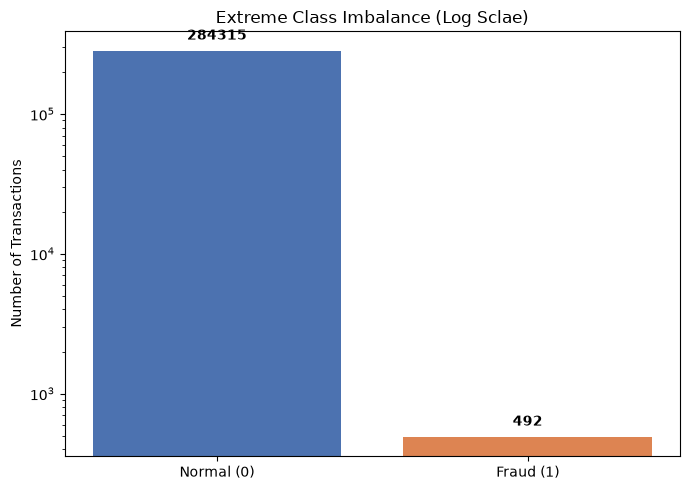

In [4]:
plt.figure(figsize=(7,5))
y_dist=y.value_counts()

bars = plt.bar(["Normal (0)", "Fraud (1)"], y_dist.values, color=['#4C72B0', '#DD8452'])
plt.yscale('log')
plt.title("Extreme Class Imbalance (Log Sclae)")
plt.ylabel("Number of Transactions")

for bar in bars:
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,yval*1.2, int(yval), ha='center',fontweight='bold')
plt.tight_layout()
plt.show()

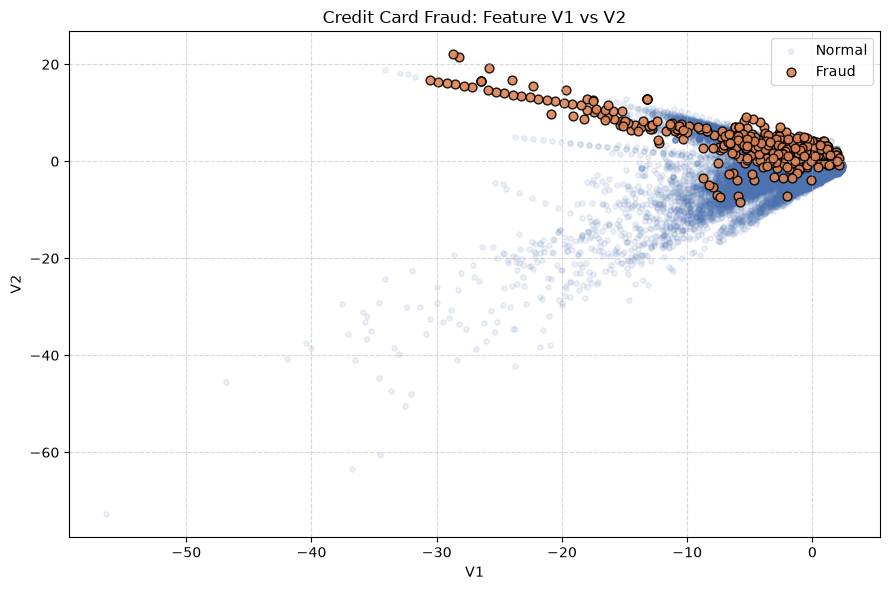

In [5]:
plt.figure(figsize=(9, 6))

# Separate the classes so we can plot Fraud ON TOP of Normal
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

# Plot Normal first (faded blue, small dots)
plt.scatter(normal['V1'], normal['V2'], color='#4C72B0', alpha=0.1, s=15, label='Normal')

# Plot Fraud on top (solid red, larger dots with borders)
plt.scatter(fraud['V1'], fraud['V2'], color='#DD8452', alpha=0.9, s=40, edgecolors='k', label='Fraud')

plt.title('Credit Card Fraud: Feature V1 vs V2')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## **Model Training**

In [6]:
RF=RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

---
## **Model Evaluation on default (0.5) threshold**

In [7]:
y_pred=RF.predict(X_test)


acc=accuracy_score(y_test, y_pred)
prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,RF.predict_proba(X_test)[:, 1])
pr_auc=average_precision_score(y_test,RF.predict_proba(X_test)[:, 1])


print("==RandomForest==\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred))
print("Classification Report : \n")
print(classification_report(y_test, y_pred, digits=4))


==RandomForest==

Accuracy : 0.9996
Precision: 0.9667
Recall   : 0.7838
F1       : 0.8657
ROC-AUC  : 0.9365
PR-AUC   : 0.8235
Confusion matrix:

[[85291     4]
 [   32   116]]
Classification Report : 

              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     85295
           1     0.9667    0.7838    0.8657       148

    accuracy                         0.9996     85443
   macro avg     0.9831    0.8919    0.9327     85443
weighted avg     0.9996    0.9996    0.9996     85443



---
## **Calculating Best Threshold**

In [8]:
probs = RF.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_threshold = float(thresholds[np.argmax(f1_scores[:-1])])

---
## **Model Evaluation on `best_threshold` (0.4300)**

In [9]:
# 1. Apply the new threshold to the raw probabilities
# This returns True/False, which .astype(int) converts to 1 and 0
y_pred_custom = (probs >= best_threshold).astype(int)

# 2. Recalculate the metrics using the new custom predictions
acc_custom = accuracy_score(y_test, y_pred_custom)
prec_custom = precision_score(y_test, y_pred_custom)
rec_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

# Note: ROC-AUC and PR-AUC don't change because they evaluate ALL thresholds, 
# not just one specific cutoff.

print(f"=== RandomForest (Optimized Threshold: {best_threshold:.4f}) ===\n")
print(f"Accuracy : {acc_custom:.4f}")
print(f"Precision: {prec_custom:.4f}")
print(f"Recall   : {rec_custom:.4f}")
print(f"F1       : {f1_custom:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f} (Unchanged)")
print(f"PR-AUC   : {pr_auc:.4f} (Unchanged)")
print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report : \n")
print(classification_report(y_test, y_pred_custom, digits=4))

=== RandomForest (Optimized Threshold: 0.4300) ===

Accuracy : 0.9996
Precision: 0.9516
Recall   : 0.7973
F1       : 0.8676
ROC-AUC  : 0.9365 (Unchanged)
PR-AUC   : 0.8235 (Unchanged)

Confusion matrix:

[[85289     6]
 [   30   118]]

Classification Report : 

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     85295
           1     0.9516    0.7973    0.8676       148

    accuracy                         0.9996     85443
   macro avg     0.9756    0.8986    0.9337     85443
weighted avg     0.9996    0.9996    0.9996     85443



---
## **Saving Model with`best_threshold` (0.43)**

In [ ]:

joblib.dump(RF, "/run/media/haroon/Local Disk (D:)/Github/Credit-Card-Fraud-Detection-System/model/fraud_model.joblib")
joblib.dump({"threshold": best_threshold, "feature_names": list(X.columns)}, "/run/media/haroon/Local Disk (D:)/Github/Credit-Card-Fraud-Detection-System/model/model_meta.joblib")

print(f"Saved model + metadata. Chosen threshold: {best_threshold:.4f}")

Saved model + metadata. Chosen threshold: 0.4300
